# AI-1: Analisis Kepuasan & Sentimen

Notebook ini untuk eksperimen dan training pipeline **AI-1**:
- Normalisasi nilai Likert ke skala 0-1
- Hitung skor kepuasan keseluruhan per responden
- Analisis sentimen teks menggunakan IndoBERT
- Hitung distribusi sentimen
- Analisis korelasi antar aspek dengan skor kepuasan

## Cara Pakai:
1. **Dataset Dummy**: Jalankan cell-cell di bawah untuk test dengan data dummy
2. **Dataset Real**: Ganti fungsi `load_dummy_dataset()` dengan loader CSV/JSON Anda sendiri
3. **Export Hasil**: Hasil AI-1 bisa diexport untuk digunakan di AI-2 (Segmentasi)


In [13]:
# Install dependencies jika belum ada
%pip install pandas numpy scikit-learn scipy matplotlib seaborn


Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.2 -> 25.3
[notice] To update, run: python.exe -m pip install --upgrade pip


In [14]:
import sys
import os
from pathlib import Path
import json

# Add parent directory to path untuk import service
notebook_dir = Path().resolve()
# Dari: service_python/ai_training/satisfaction_analysis/
# Ke: service_python/
project_root = notebook_dir.parent.parent
sys.path.insert(0, str(project_root))

# Alternatif: jika menjalankan dari root project
if not (project_root / "app").exists():
    cwd = Path.cwd()
    if (cwd / "app").exists():
        project_root = cwd
        sys.path.insert(0, str(project_root))

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
try:
    import seaborn as sns
except ImportError:
    print("⚠️  seaborn tidak terinstall, beberapa visualisasi mungkin tidak tersedia")
    sns = None
from typing import List, Dict, Any, Optional

# Import service AI-1
# Setelah menambahkan project_root ke sys.path, gunakan import relatif dari app
try:
    from app.src.services.satisfaction_analysis_service import analyze_satisfaction
    print("✅ Import berhasil menggunakan: app.src.services...")
except ImportError as e1:
    try:
        # Fallback: coba dengan service_python prefix
        from service_python.app.src.services.satisfaction_analysis_service import analyze_satisfaction
        print("✅ Import berhasil menggunakan: service_python.app.src.services...")
    except ImportError as e2:
        # Fallback terakhir: coba import langsung dari file
        import importlib.util
        service_path = project_root / "app" / "src" / "services" / "satisfaction_analysis_service.py"
        if service_path.exists():
            spec = importlib.util.spec_from_file_location("satisfaction_analysis_service", service_path)
            module = importlib.util.module_from_spec(spec)
            spec.loader.exec_module(module)
            analyze_satisfaction = module.analyze_satisfaction
            print("✅ Import berhasil menggunakan: importlib (direct file)")
        else:
            raise ImportError(
                f"Tidak bisa import service. Pastikan path benar.\n"
                f"  Project root: {project_root}\n"
                f"  Service path: {service_path}\n"
                f"  Error 1: {e1}\n"
                f"  Error 2: {e2}"
            )

print("✅ Imports berhasil!")
print(f"Working directory: {notebook_dir}")
print(f"Project root: {project_root}")
print(f"App directory exists: {(project_root / 'app').exists()}")


✅ Import berhasil menggunakan: app.src.services...
✅ Imports berhasil!
Working directory: C:\Users\User\OneDrive\Documents\3312411050\SEMESTER 3\PBL-2AI\SurvaAnalytics\service_python\ai_training\satisfaction_analysis
Project root: C:\Users\User\OneDrive\Documents\3312411050\SEMESTER 3\PBL-2AI\SurvaAnalytics\service_python
App directory exists: True


## 1. Load Dataset

Fungsi di bawah ini untuk generate dataset dummy. **Ganti fungsi ini dengan loader CSV/JSON Anda sendiri** untuk dataset real.


In [15]:
def load_dummy_dataset() -> List[Dict[str, Any]]:
    """
    Generate dataset dummy untuk testing.
    
    TODO: Ganti fungsi ini dengan loader CSV/JSON Anda sendiri.
    Contoh struktur CSV yang diharapkan:
    - text: kolom teks opini (optional)
    - likert_service_quality: nilai Likert untuk service quality
    - likert_price_fairness: nilai Likert untuk price fairness
    - likert_accessibility: nilai Likert untuk accessibility
    - categorical features lainnya (untuk AI-2)
    """
    
    responses = [
        {
            "text": "Pelayanan sangat cepat dan ramah, saya puas sekali dengan kualitasnya.",
            "likert": {
                "service_quality": 5,
                "price_fairness": 4,
                "accessibility": 5,
            },
            "categorical": {
                "age": 21,
                "female": 1,
                "male": 0,
            },
        },
        {
            "text": "Harganya terlalu mahal, tapi kualitas cukup baik dan mudah diakses.",
            "likert": {
                "service_quality": 4,
                "price_fairness": 2,
                "accessibility": 3,
            },
            "categorical": {
                "age": 30,
                "female": 0,
                "male": 1,
            },
        },
        {
            "text": "Sulit diakses dan respon CS lama, saya kurang puas dengan pelayanan.",
            "likert": {
                "service_quality": 2,
                "price_fairness": 3,
                "accessibility": 1,
            },
            "categorical": {
                "age": 25,
                "female": 0,
                "male": 1,
            },
        },
        {
            "text": "Produknya bagus, harga wajar, tapi aksesnya agak jauh dari rumah.",
            "likert": {
                "service_quality": 4,
                "price_fairness": 4,
                "accessibility": 2,
            },
            "categorical": {
                "age": 28,
                "female": 1,
                "male": 0,
            },
        },
        {
            "text": "Sangat puas dengan semua aspek, pelayanan, harga, dan akses semuanya memuaskan.",
            "likert": {
                "service_quality": 5,
                "price_fairness": 5,
                "accessibility": 5,
            },
            "categorical": {
                "age": 35,
                "female": 1,
                "male": 0,
            },
        },
        {
            "text": "Harga murah tapi kualitas kurang, pelayanan biasa saja.",
            "likert": {
                "service_quality": 3,
                "price_fairness": 4,
                "accessibility": 3,
            },
            "categorical": {
                "age": 22,
                "female": 0,
                "male": 1,
            },
        },
    ]
    
    return responses


# Load dataset
responses = load_dummy_dataset()
print(f"✅ Dataset loaded: {len(responses)} responden")
print(f"\nContoh data responden pertama:")
print(f"  Text: {responses[0]['text'][:50]}...")
print(f"  Likert: {responses[0]['likert']}")


✅ Dataset loaded: 6 responden

Contoh data responden pertama:
  Text: Pelayanan sangat cepat dan ramah, saya puas sekali...
  Likert: {'service_quality': 5, 'price_fairness': 4, 'accessibility': 5}


In [16]:
# Jalankan AI-1: Analisis Kepuasan
likert_min = 1.0
likert_max = 5.0

result_ai1 = analyze_satisfaction(
    responses=responses,
    likert_min=likert_min,
    likert_max=likert_max,
)

print("=" * 60)
print("AI-1: HASIL ANALISIS KEPUASAN & SENTIMEN")
print("=" * 60)

print(f"\n📊 Skor Kepuasan Keseluruhan (0-1):")
for i, score in enumerate(result_ai1["overall_satisfaction_scores"]):
    print(f"  Responden {i+1}: {score:.3f}")

print(f"\n💬 Label Sentimen:")
for i, label in enumerate(result_ai1["sentiment_labels"]):
    print(f"  Responden {i+1}: {label}")

print(f"\n📈 Skor Sentimen (0-1):")
for i, score in enumerate(result_ai1["sentiment_scores"]):
    score_str = f"{score:.3f}" if score is not None else "N/A"
    print(f"  Responden {i+1}: {score_str}")

print(f"\n📊 Distribusi Sentimen:")
for label, count in result_ai1["sentiment_distribution"].items():
    print(f"  {label.capitalize()}: {count}")

print(f"\n🔗 Korelasi Aspek dengan Kepuasan Keseluruhan:")
for aspect, corr in result_ai1["likert_correlation"].items():
    print(f"  {aspect}:")
    print(f"    Pearson:  {corr['pearson']:.3f}")
    print(f"    Spearman: {corr['spearman']:.3f}")


Asking to truncate to max_length but no maximum length is provided and the model has no predefined maximum length. Default to no truncation.


AI-1: HASIL ANALISIS KEPUASAN & SENTIMEN

📊 Skor Kepuasan Keseluruhan (0-1):
  Responden 1: 0.917
  Responden 2: 0.500
  Responden 3: 0.250
  Responden 4: 0.583
  Responden 5: 1.000
  Responden 6: 0.583

💬 Label Sentimen:
  Responden 1: positive
  Responden 2: positive
  Responden 3: negative
  Responden 4: positive
  Responden 5: positive
  Responden 6: neutral

📈 Skor Sentimen (0-1):
  Responden 1: 0.940
  Responden 2: 0.510
  Responden 3: 0.520
  Responden 4: 0.630
  Responden 5: 0.910
  Responden 6: 0.500

📊 Distribusi Sentimen:
  Positive: 4
  Negative: 1
  Neutral: 1
  Unknown: 0

🔗 Korelasi Aspek dengan Kepuasan Keseluruhan:
  service_quality:
    Pearson:  0.909
    Spearman: 0.851
  price_fairness:
    Pearson:  0.718
    Spearman: 0.893
  accessibility:
    Pearson:  0.951
    Spearman: 0.851


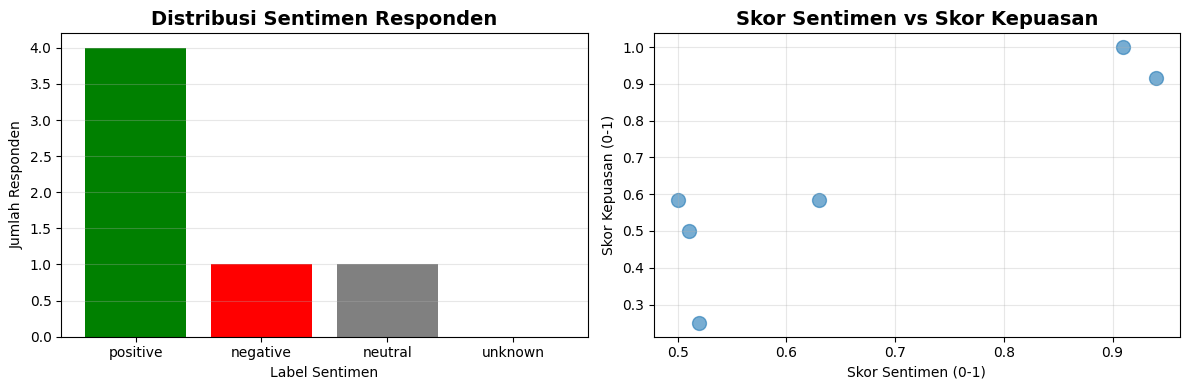

In [17]:
# Visualisasi: Distribusi Sentimen
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Plot 1: Distribusi Sentimen
sentiment_dist = result_ai1["sentiment_distribution"]
labels = list(sentiment_dist.keys())
counts = list(sentiment_dist.values())

axes[0].bar(labels, counts, color=['green', 'red', 'gray', 'orange'])
axes[0].set_title('Distribusi Sentimen Responden', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Label Sentimen')
axes[0].set_ylabel('Jumlah Responden')
axes[0].grid(axis='y', alpha=0.3)

# Plot 2: Skor Kepuasan vs Sentimen
satisfaction_scores = result_ai1["overall_satisfaction_scores"]
sentiment_scores = [s if s is not None else 0.5 for s in result_ai1["sentiment_scores"]]

axes[1].scatter(sentiment_scores, satisfaction_scores, alpha=0.6, s=100)
axes[1].set_title('Skor Sentimen vs Skor Kepuasan', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Skor Sentimen (0-1)')
axes[1].set_ylabel('Skor Kepuasan (0-1)')
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()


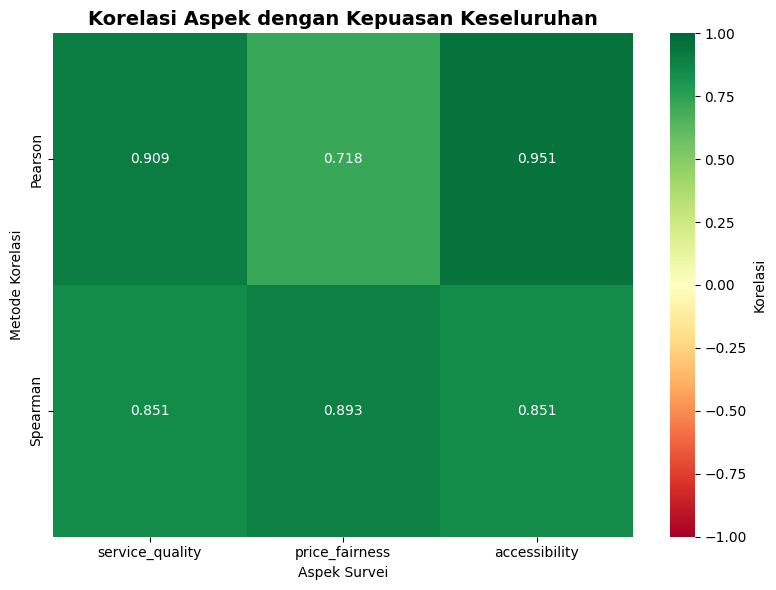

In [18]:
# Visualisasi: Heatmap Korelasi
corr_data = result_ai1["likert_correlation"]
if corr_data and sns is not None:
    aspects = list(corr_data.keys())
    pearson_vals = [corr_data[a]["pearson"] for a in aspects]
    spearman_vals = [corr_data[a]["spearman"] for a in aspects]
    
    corr_df = pd.DataFrame({
        'Pearson': pearson_vals,
        'Spearman': spearman_vals
    }, index=aspects)
    
    plt.figure(figsize=(8, 6))
    sns.heatmap(corr_df.T, annot=True, fmt='.3f', cmap='RdYlGn', center=0,
                vmin=-1, vmax=1, cbar_kws={'label': 'Korelasi'})
    plt.title('Korelasi Aspek dengan Kepuasan Keseluruhan', fontsize=14, fontweight='bold')
    plt.ylabel('Metode Korelasi')
    plt.xlabel('Aspek Survei')
    plt.tight_layout()
    plt.show()
elif corr_data:
    # Fallback jika seaborn tidak tersedia
    aspects = list(corr_data.keys())
    pearson_vals = [corr_data[a]["pearson"] for a in aspects]
    spearman_vals = [corr_data[a]["spearman"] for a in aspects]
    
    x = np.arange(len(aspects))
    width = 0.35
    
    fig, ax = plt.subplots(figsize=(10, 6))
    ax.bar(x - width/2, pearson_vals, width, label='Pearson', alpha=0.8)
    ax.bar(x + width/2, spearman_vals, width, label='Spearman', alpha=0.8)
    
    ax.set_xlabel('Aspek Survei')
    ax.set_ylabel('Korelasi')
    ax.set_title('Korelasi Aspek dengan Kepuasan Keseluruhan', fontsize=14, fontweight='bold')
    ax.set_xticks(x)
    ax.set_xticklabels(aspects, rotation=45, ha='right')
    ax.legend()
    ax.grid(axis='y', alpha=0.3)
    plt.tight_layout()
    plt.show()


## 3. Export Hasil AI-1

Export hasil untuk digunakan di AI-2 (Segmentasi) atau analisis lebih lanjut.


In [19]:
# Buat DataFrame lengkap dengan hasil AI-1
df_results = pd.DataFrame({
    'respondent_id': range(1, len(responses) + 1),
    'text': [r.get('text', '') for r in responses],
    'satisfaction_score': result_ai1["overall_satisfaction_scores"],
    'sentiment_label': result_ai1["sentiment_labels"],
    'sentiment_score': [s if s is not None else 0.5 for s in result_ai1["sentiment_scores"]],
})

# Tambahkan kolom Likert yang sudah dinormalisasi
likert_norm = result_ai1["likert_normalized"]
for i, likert_dict in enumerate(likert_norm):
    for key, value in likert_dict.items():
        df_results[f'likert_{key}_normalized'] = [likert_norm[j].get(key, np.nan) 
                                                    for j in range(len(likert_norm))]

print("=" * 60)
print("RINGKASAN HASIL AI-1")
print("=" * 60)
print("\n📊 DataFrame Hasil:")
print(df_results.head(10))

# Export ke CSV
output_file = 'satisfaction_analysis_results.csv'
df_results.to_csv(output_file, index=False)
print(f"\n✅ Hasil diexport ke: {output_file}")

# Export ke JSON untuk digunakan di AI-2
output_json = {
    'satisfaction_scores': result_ai1["overall_satisfaction_scores"],
    'sentiment_scores': [s if s is not None else 0.5 for s in result_ai1["sentiment_scores"]],
    'sentiment_labels': result_ai1["sentiment_labels"],
    'likert_normalized': result_ai1["likert_normalized"],
    'categorical_features': [r.get('categorical', {}) for r in responses],
}

json_file = 'satisfaction_analysis_results.json'
with open(json_file, 'w', encoding='utf-8') as f:
    json.dump(output_json, f, indent=2, ensure_ascii=False)
print(f"✅ Hasil JSON diexport ke: {json_file} (untuk digunakan di AI-2)")


RINGKASAN HASIL AI-1

📊 DataFrame Hasil:
   respondent_id                                               text  \
0              1  Pelayanan sangat cepat dan ramah, saya puas se...   
1              2  Harganya terlalu mahal, tapi kualitas cukup ba...   
2              3  Sulit diakses dan respon CS lama, saya kurang ...   
3              4  Produknya bagus, harga wajar, tapi aksesnya ag...   
4              5  Sangat puas dengan semua aspek, pelayanan, har...   
5              6  Harga murah tapi kualitas kurang, pelayanan bi...   

   satisfaction_score sentiment_label  sentiment_score  \
0            0.916667        positive             0.94   
1            0.500000        positive             0.51   
2            0.250000        negative             0.52   
3            0.583333        positive             0.63   
4            1.000000        positive             0.91   
5            0.583333         neutral             0.50   

   likert_service_quality_normalized  likert_price_fai

## 4. Helper Function: Load Dataset dari CSV

Contoh fungsi untuk load dataset dari CSV. **Sesuaikan dengan struktur CSV Anda sendiri.**


In [20]:
def load_dataset_from_csv(csv_path: str) -> List[Dict[str, Any]]:
    """
    Load dataset dari CSV file.
    
    Contoh struktur CSV yang diharapkan:
    - text: kolom teks opini (optional, bisa kosong)
    - likert_service_quality: nilai Likert untuk service quality (1-5)
    - likert_price_fairness: nilai Likert untuk price fairness (1-5)
    - likert_accessibility: nilai Likert untuk accessibility (1-5)
    - categorical features lainnya (untuk AI-2)
    
    Sesuaikan kolom-kolom ini dengan struktur CSV Anda sendiri.
    """
    df = pd.read_csv(csv_path)
    responses = []
    
    for _, row in df.iterrows():
        # Extract Likert scores (kolom yang dimulai dengan 'likert_')
        likert_dict = {}
        for col in df.columns:
            if col.startswith('likert_'):
                aspect_name = col.replace('likert_', '')
                likert_dict[aspect_name] = float(row[col])
        
        # Extract categorical features (opsional, untuk AI-2)
        categorical_dict = {}
        if 'age' in df.columns:
            categorical_dict['age'] = float(row['age'])
        if 'gender' in df.columns:
            gender = str(row['gender']).lower()
            categorical_dict['female'] = 1 if gender == 'female' else 0
            categorical_dict['male'] = 1 if gender == 'male' else 0
        
        # Text (optional)
        text = None
        if 'text' in df.columns:
            text_val = row['text']
            if pd.notna(text_val) and str(text_val).strip():
                text = str(text_val).strip()
        
        responses.append({
            "text": text,
            "likert": likert_dict,
            "categorical": categorical_dict,
        })
    
    return responses


# Contoh penggunaan (uncomment jika sudah punya CSV):
# csv_path = './dataset/your_survey_data.csv'
# responses = load_dataset_from_csv(csv_path)
# print(f"✅ Dataset loaded from CSV: {len(responses)} responden")
